# Exploratory Data Analysis

## Objective
Explore the Bank Marketing dataset to understand:
- Target variable distribution and class imbalance
- Numerical variable distributions, outliers, and skewness
- Categorical variable distributions and response rates by group
- Relationships between features and the target
- Potential leakage variables (especially `duration`)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuration
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
RANDOM_STATE = 42
%matplotlib inline

df = pd.read_csv('../data/raw/bank_marketing.csv')
print(f"Dataset loaded: {df.shape}")

Dataset loaded: (45211, 17)


## 1. Target Variable Distribution

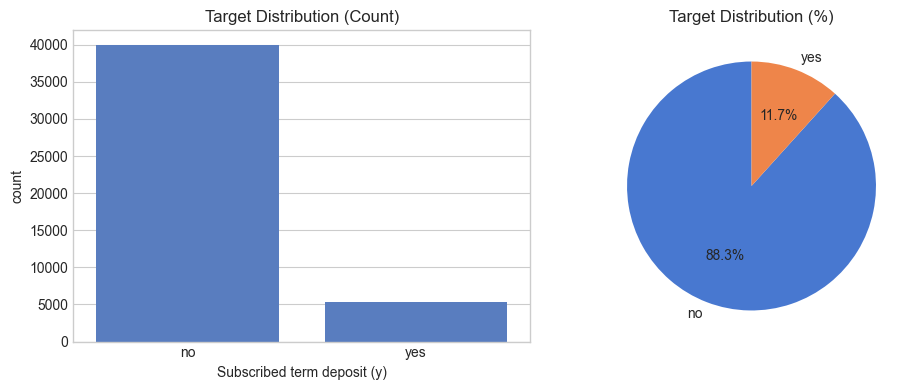

y
no     88.3
yes    11.7
Name: proportion, dtype: float64


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count
sns.countplot(x='y', data=df, ax=axes[0])
axes[0].set_title('Target Distribution (Count)')
axes[0].set_xlabel('Subscribed term deposit (y)')

# Percentage
target_pct = df['y'].value_counts(normalize=True) * 100
axes[1].pie(target_pct.values, labels=target_pct.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Target Distribution (%)')

plt.tight_layout()
plt.savefig('../reports/figures/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(df['y'].value_counts(normalize=True).mul(100).round(1))

**Finding:** The dataset is significantly imbalanced — only ~11.7% of customers subscribed.  
Accuracy alone will be misleading. We will prioritise F1, Recall, and PR-AUC as evaluation metrics.

## 2. Numerical Variables — Distributions

In [3]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Numerical columns:", num_cols)

df[num_cols].describe().round(2)

Numerical columns: ['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']


,age,balance,day_of_week,duration,campaign,pdays,previous
count,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00
mean,40.94,1362.27,15.81,258.16,2.76,40.20,0.58
std,10.62,3044.77,8.32,257.53,3.10,100.13,2.30
min,18.00,-8019.00,1.00,0.00,1.00,-1.00,0.00
25%,33.00,72.00,8.00,103.00,1.00,-1.00,0.00
50%,39.00,448.00,16.00,180.00,2.00,-1.00,0.00
75%,48.00,1428.00,21.00,319.00,3.00,-1.00,0.00
max,95.00,102127.00,31.00,4918.00,63.00,871.00,275.00


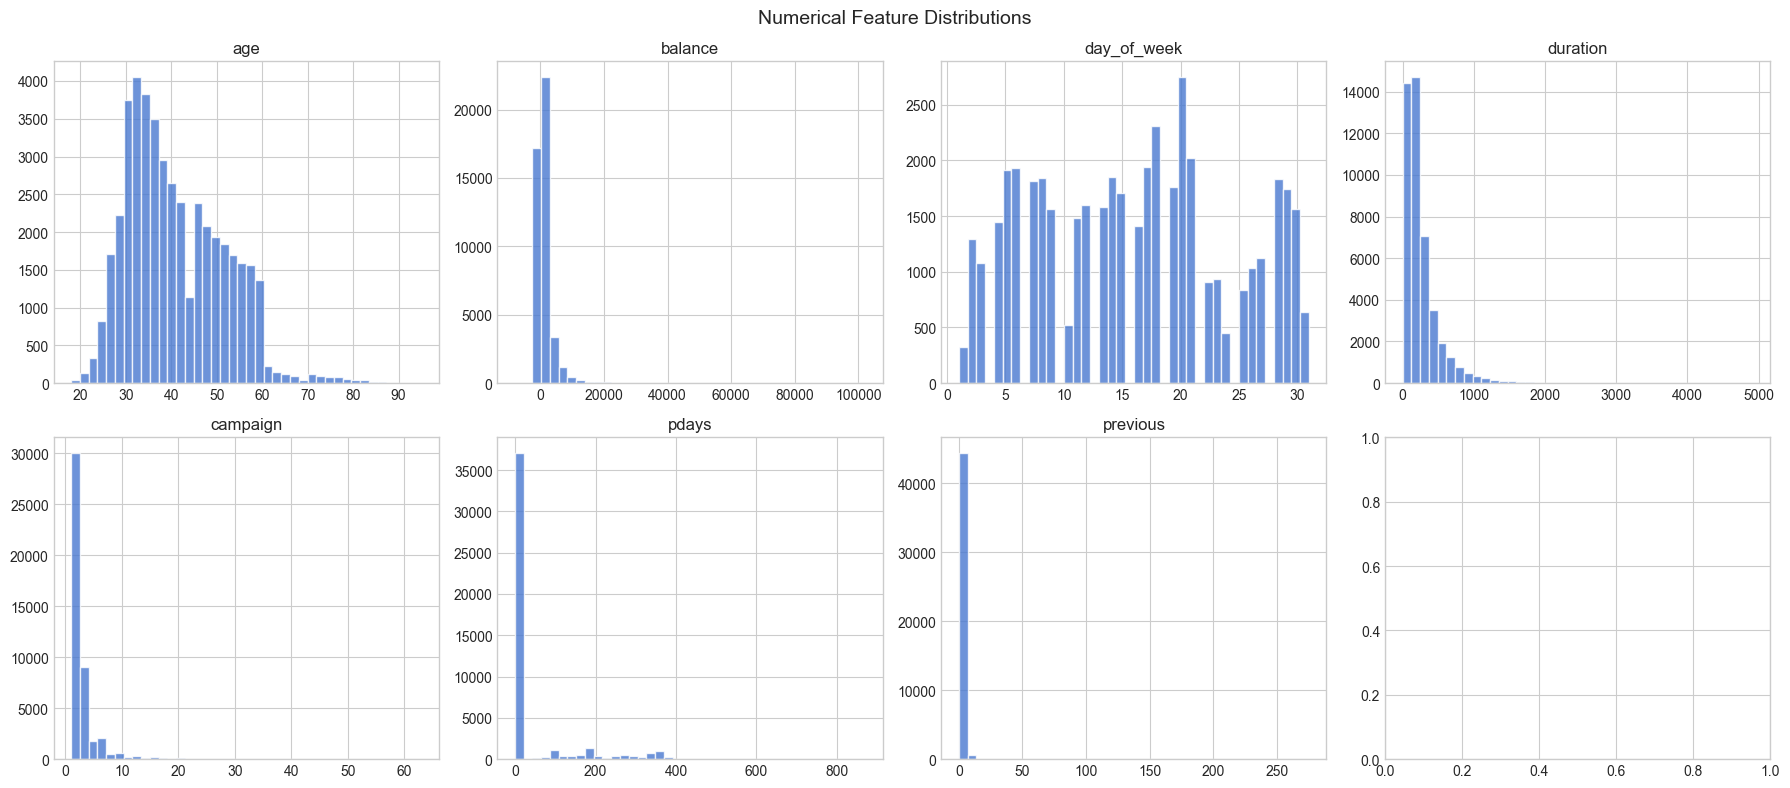

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, edgecolor='white', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Numerical Feature Distributions', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/numerical_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Numerical Variables — By Target Class

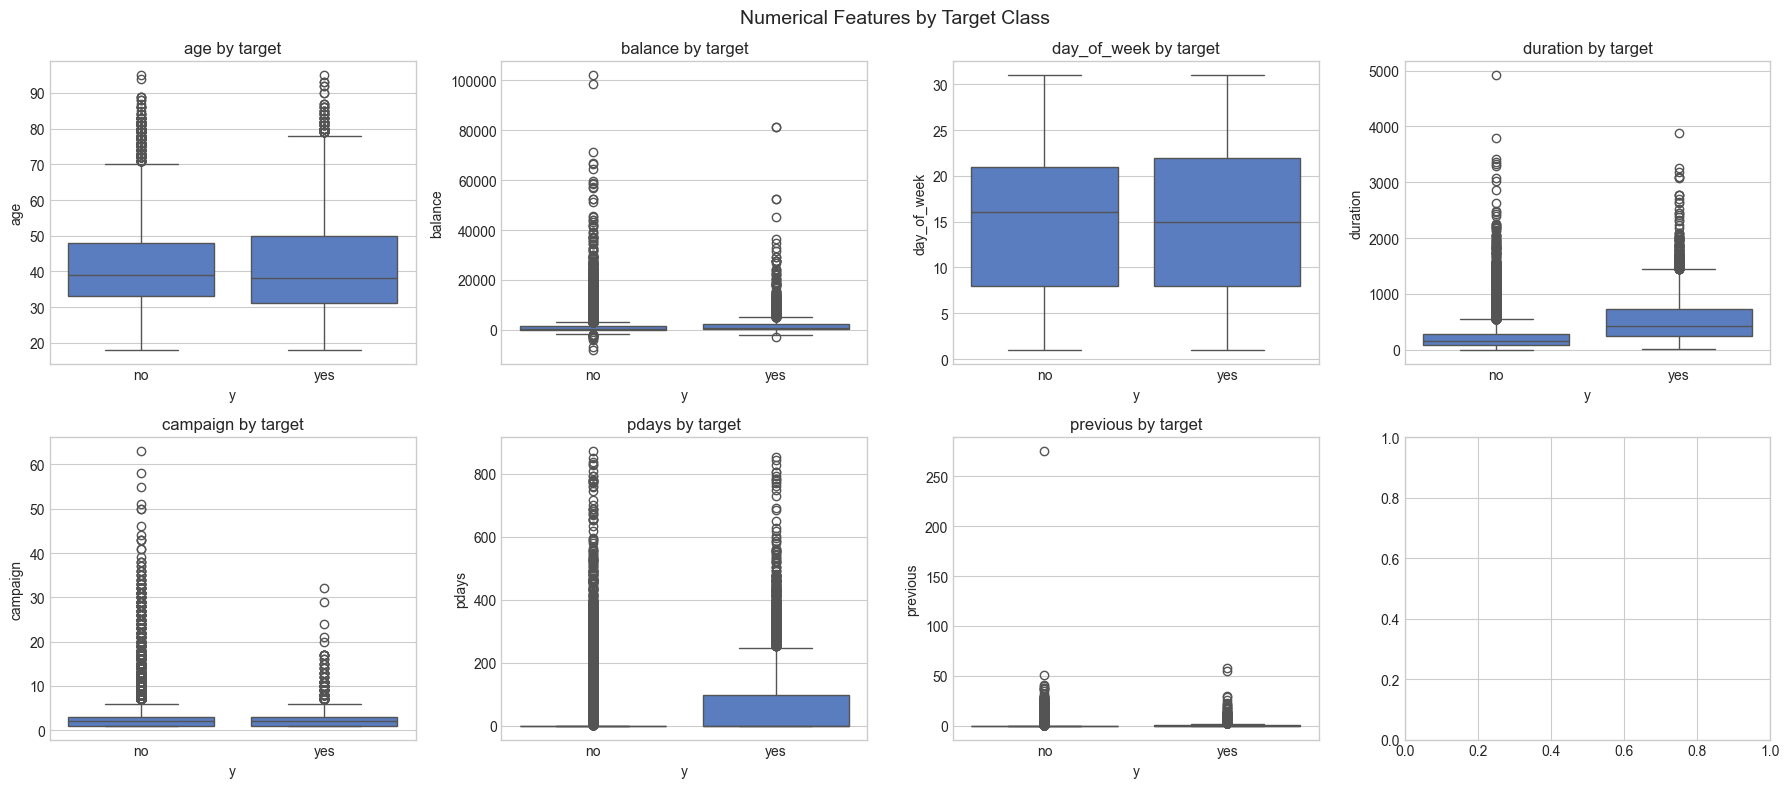

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x='y', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} by target')

plt.suptitle('Numerical Features by Target Class', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/numerical_by_target.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Leakage Investigation — `duration`

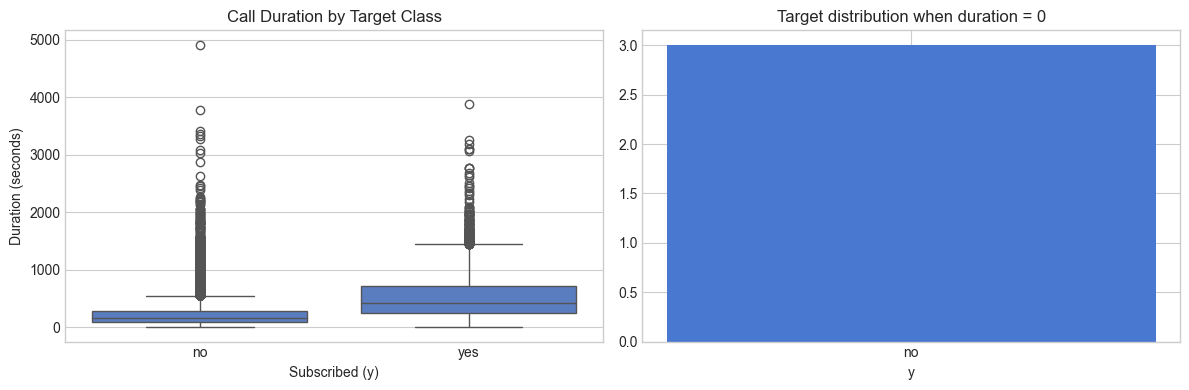

When duration = 0:
y
no    3
Name: count, dtype: int64

Conclusion: duration is only known AFTER the call — it must be excluded to prevent target leakage.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x='y', y='duration', data=df, ax=axes[0])
axes[0].set_title('Call Duration by Target Class')
axes[0].set_xlabel('Subscribed (y)')
axes[0].set_ylabel('Duration (seconds)')

# Duration = 0 almost always means no subscription
zero_dur = df[df['duration'] == 0]['y'].value_counts()
axes[1].bar(zero_dur.index, zero_dur.values)
axes[1].set_title('Target distribution when duration = 0')
axes[1].set_xlabel('y')

plt.tight_layout()
plt.savefig('../reports/figures/duration_leakage.png', dpi=150, bbox_inches='tight')
plt.show()

print("When duration = 0:")
print(df[df['duration'] == 0]['y'].value_counts())
print("\nConclusion: duration is only known AFTER the call — it must be excluded to prevent target leakage.")

## 5. Categorical Variables — Response Rate by Group

In [7]:
cat_cols = [c for c in df.select_dtypes(include='object').columns if c != 'y']
print("Categorical columns:", cat_cols)

# Response rate per category
for col in cat_cols:
    rate = df.groupby(col)['y'].apply(lambda x: (x == 'yes').mean() * 100).round(1)
    print(f"\nResponse rate (%) by {col}:")
    print(rate.sort_values(ascending=False).to_string())

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Response rate (%) by job:
job
student          28.7
retired          22.8
unemployed       15.5
management       13.8
admin.           12.2
self-employed    11.8
technician       11.1
services          8.9
housemaid         8.8
entrepreneur      8.3
blue-collar       7.3

Response rate (%) by marital:
marital
single      14.9
divorced    11.9
married     10.1

Response rate (%) by education:
education
tertiary     15.0
secondary    10.6
primary       8.6

Response rate (%) by default:
default
no     11.8
yes     6.4

Response rate (%) by housing:
housing
no     16.7
yes     7.7

Response rate (%) by loan:
loan
no     12.7
yes     6.7

Response rate (%) by contact:
contact
cellular     14.9
telephone    13.4

Response rate (%) by month:
month
mar    52.0
dec    46.7
sep    46.5
oct    43.8
apr    19.7
feb    16.6
aug    11.0
jun    10.2
nov    10.2
jan    10.1
jul     9.1


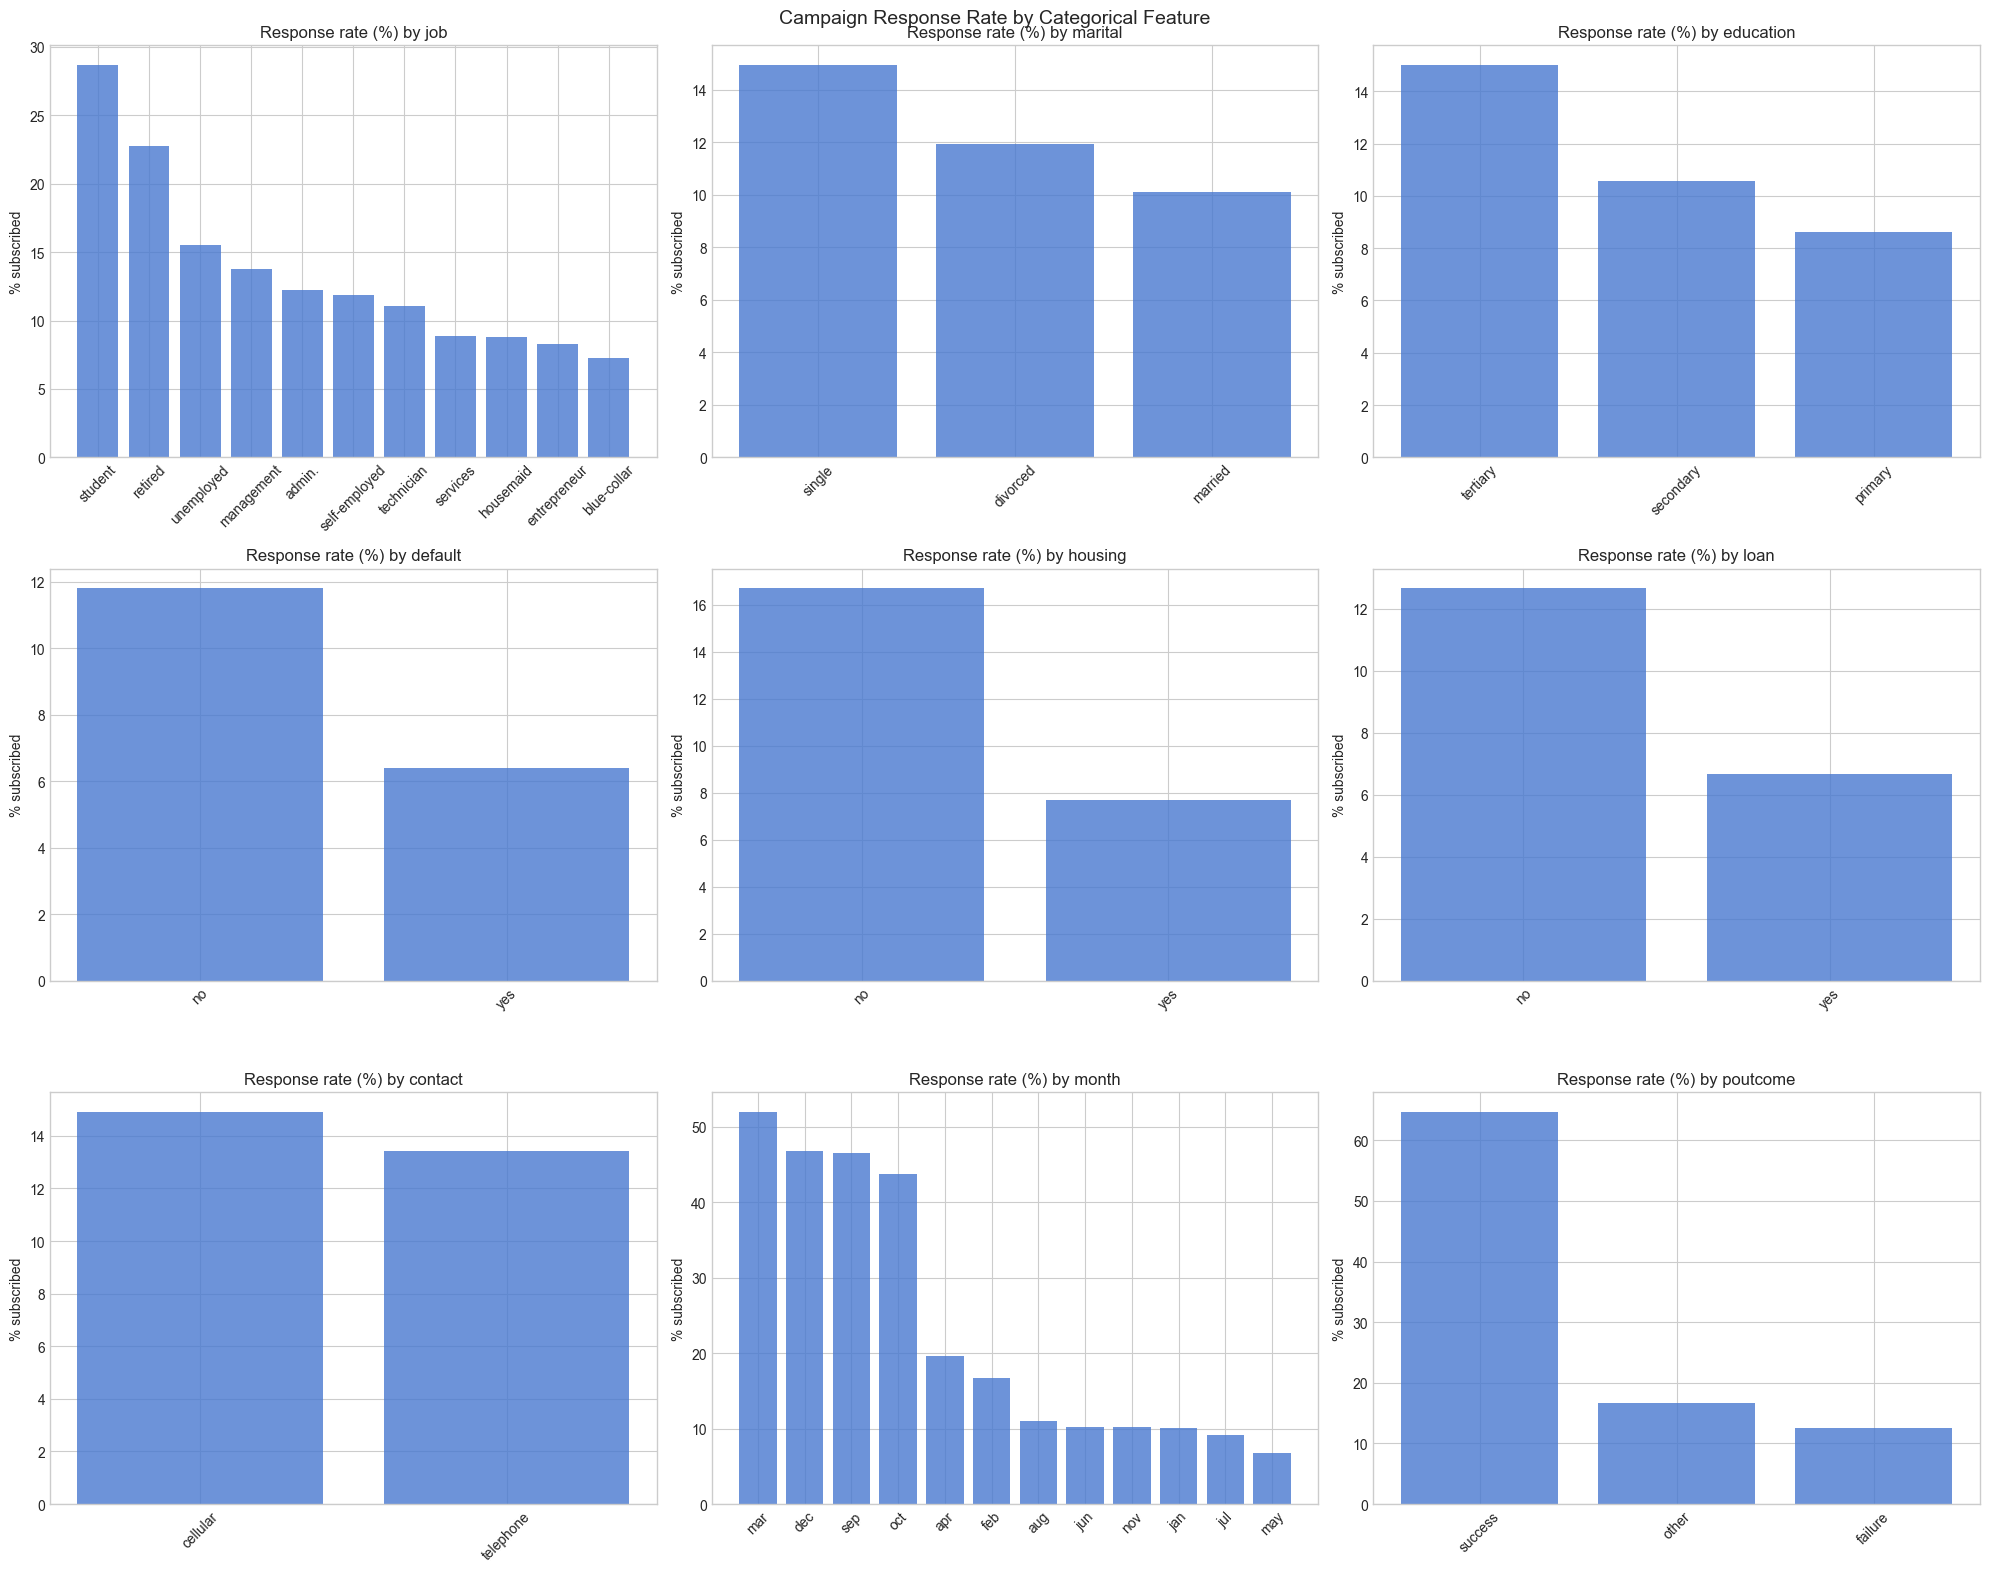

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    rate = df.groupby(col)['y'].apply(lambda x: (x == 'yes').mean() * 100).sort_values(ascending=False)
    axes[i].bar(rate.index, rate.values, alpha=0.8)
    axes[i].set_title(f'Response rate (%) by {col}')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('% subscribed')

# Hide unused subplots
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Campaign Response Rate by Categorical Feature', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/categorical_response_rates.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Unknown / Missing Value Analysis

In [9]:
print("'unknown' value counts and response rates:\n")
for col in cat_cols:
    n_unknown = (df[col] == 'unknown').sum()
    if n_unknown > 0:
        rate_unknown = (df[df[col] == 'unknown']['y'] == 'yes').mean() * 100
        rate_known   = (df[df[col] != 'unknown']['y'] == 'yes').mean() * 100
        print(f"{col}: {n_unknown} unknowns ({n_unknown/len(df)*100:.1f}%)")
        print(f"  Response rate: unknown={rate_unknown:.1f}%  |  known={rate_known:.1f}%")

'unknown' value counts and response rates:



## Key Findings

| Finding | Evidence | Why It Matters | Decision / Action |
|---------|----------|----------------|-------------------|
| Target is highly imbalanced | 88.3% no, 11.7% yes | Accuracy is misleading | Use F1, Recall, PR-AUC; stratified splits; explore class weights |
| `duration` leaks the target | duration=0 → almost always 'no'; only known after call | Would artificially inflate performance | **Drop `duration` before modelling** |
| `poutcome` has 81.7% 'unknown' | 36,959 / 45,211 rows | Most previous campaign history is unknown | Keep 'unknown' as explicit category — it contains signal |
| `contact` has 28.8% 'unknown' | 13,020 rows | Contact method not always recorded | Keep 'unknown' as explicit category |
| `balance`, `pdays`, `campaign` are right-skewed | Long right tails visible in histograms | Outliers may affect linear models | Consider tree-based models; scale for logistic regression |

## Decisions Made

- `duration` → **excluded** (target leakage)
- `'unknown'` values in categorical columns → **retained as explicit category** (shown to carry predictive signal)
- Primary evaluation metrics → **Recall, F1, PR-AUC** (due to class imbalance)
- Class imbalance strategy → to be explored in modelling phase (class weights, SMOTE)